In [1]:
from QKRR import load_fashion_mnist, NumericalTestRisk, TheoreticalTestRisk

## Set common parameters across numerical and theoretical plots

In [2]:
N_QUBITS=3
LAMBDA_LIST=[1e-10, 1e-8, 1e-6, 1e-4, 1e-2]

X_train, y_train, X_test, y_test = load_fashion_mnist(N_QUBITS=N_QUBITS)
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}, X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

Loading from cache: /Users/kkensuke/.cache/DD_QKRR/fashion_mnist.npz
X_train shape: (8991, 6), y_train shape: (8991,), X_test shape: (5009, 6), y_test shape: (5009,)


## Numerical Test Risk

In [3]:
REPS = 100

numerical_tester = NumericalTestRisk(N_QUBITS=N_QUBITS, LAMBDA_LIST=LAMBDA_LIST, REPS=REPS)
numerical_tester.numerical_test_risk_lambda_optimized(X_train, y_train, X_test[:1000], y_test[:1000])
numerical_tester.save_results("results/QKRR_mnist_3qubits_HEA_numerical_revised.pkl")

Training sample sizes: [40, 48, 56, 64, 72, 80]
Training data available: 8991 samples, required: 8000 samples
  Completed!0


In [4]:
# numerical_tester = NumericalTestRisk(N_QUBITS=N_QUBITS, LAMBDA_LIST=LAMBDA_LIST)
# numerical_tester.load_results("results/QKRR_mnist_3qubits_HEA_numerical_revised.pkl")

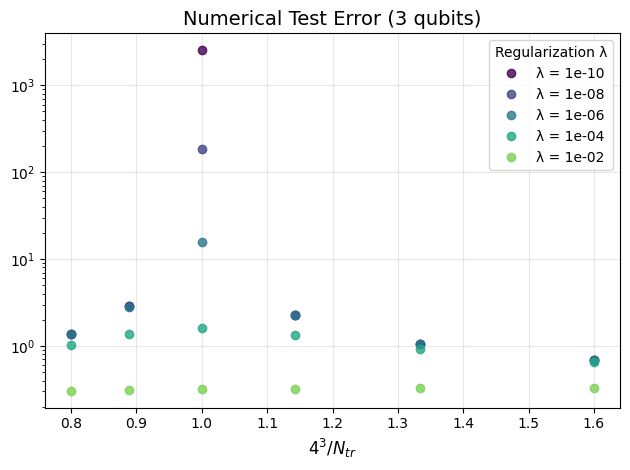

In [5]:
numerical_tester.plot_mse_test()

## Theoretical Test Risk

In [31]:
theoretical_tester = TheoreticalTestRisk(N_QUBITS=N_QUBITS, LAMBDA_LIST=LAMBDA_LIST, noise_sigma=0.5)
# Fashion-MNIST is outside the theorem's regression assumptions; observed labels on a held-out estimation subset are used as plug-in targets.
X_est = X_test[1000:4000]
target_values_est = y_test[1000:4000]
theoretical_tester.theoretical_test_risk_lambda(X_est, target_values_est)
theoretical_tester.save_results("results/QKRR_mnist_3qubits_HEA_theoretical_revised.pkl")


λ = 1e-10
  n_train = 82
λ = 1e-08
  n_train = 82
λ = 1e-06
  n_train = 82
λ = 0.0001
  n_train = 82
λ = 0.01


In [ ]:
# theoretical_tester = TheoreticalTestRisk(N_QUBITS=N_QUBITS, LAMBDA_LIST=LAMBDA_LIST, noise_sigma=0.5)
# theoretical_tester.load_results("results/QKRR_mnist_3qubits_HEA_theoretical_revised.pkl")

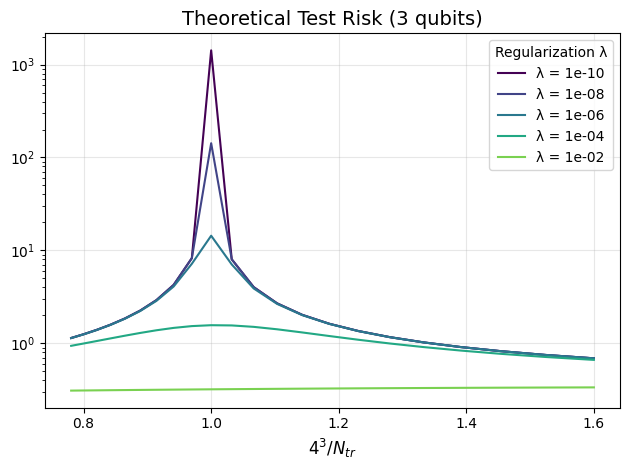

In [33]:
theoretical_tester.plot_theoretical_test()

In [34]:
# theoretical_tester.plot_effective_DOF()

<>:29: SyntaxWarning: invalid escape sequence '\g'
<>:29: SyntaxWarning: invalid escape sequence '\g'
/var/folders/9k/y9ch3jl55qd4kn1j6b53yyjw0000gn/T/ipykernel_6575/2247251695.py:29: SyntaxWarning: invalid escape sequence '\g'
  plt.xlabel(f'$\gamma = 4^{N_QUBITS}/N_{{tr}}$', fontsize=18)


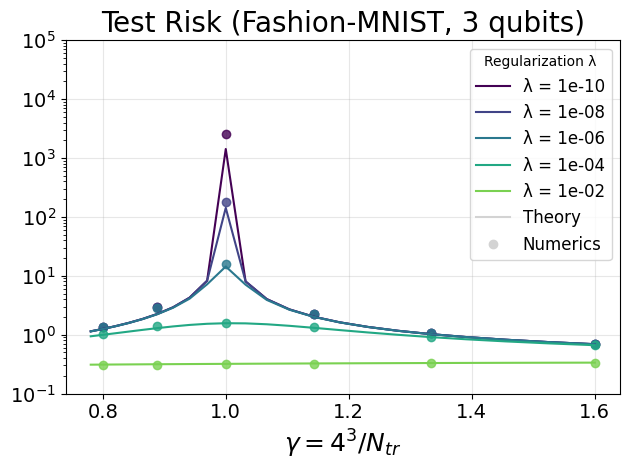

In [35]:
import numpy as np
import matplotlib.pyplot as plt

colors = plt.cm.viridis(np.linspace(0, 0.8, len(LAMBDA_LIST)))
numerical_ratio_list = 4 ** N_QUBITS / np.array(numerical_tester.n_train_list)
theoretical_ratio_list = 4 ** N_QUBITS / np.array(theoretical_tester.n_train_list)

for i, lam in enumerate(LAMBDA_LIST):
    plt.semilogy(
        numerical_ratio_list,
        numerical_tester.mse_test_all_mean[lam],
        marker='o',
        alpha=0.8,
        linestyle='none',
        color=colors[i]
    )

for i, lam in enumerate(LAMBDA_LIST):
    plt.semilogy(
        theoretical_ratio_list,
        theoretical_tester.R_theoretical_list[i],
        label=f'λ = {lam:.0e}',
        color=colors[i]
    )

plt.plot([], [], '-', color='lightgray', label='Theory')
plt.plot([], [], 'o', color='lightgray', label='Numerics')

plt.xlabel(f'$\gamma = 4^{N_QUBITS}/N_{{tr}}$', fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(1e-1, 1e5)
plt.title(f'Test Risk (Fashion-MNIST, {N_QUBITS} qubits)', fontsize=20)
plt.legend(title='Regularization λ', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'results/QKRR_mnist_{N_QUBITS}qubits_HEA.pdf')